In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
np.random.seed(42)
X, y = make_blobs(n_samples=300, centers=4, cluster_std=1.5, random_state=42)

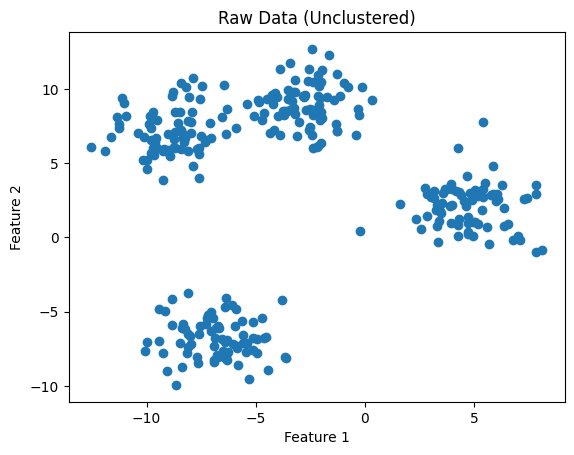

In [2]:
plt.figure()
plt.scatter(X[:, 0], X[:, 1])
plt.title("Raw Data (Unclustered)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

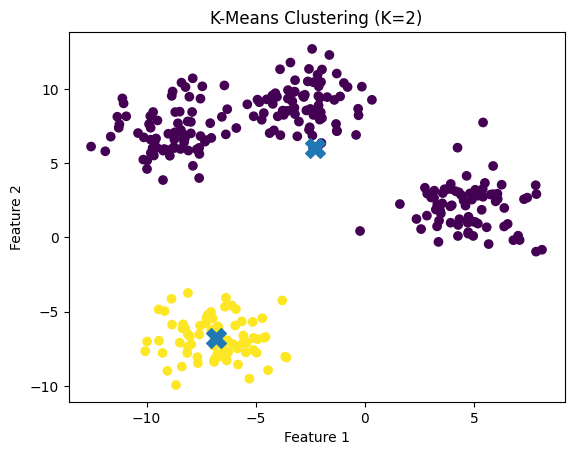

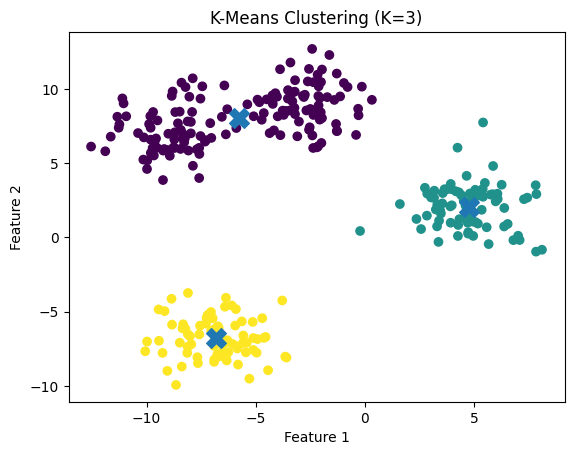

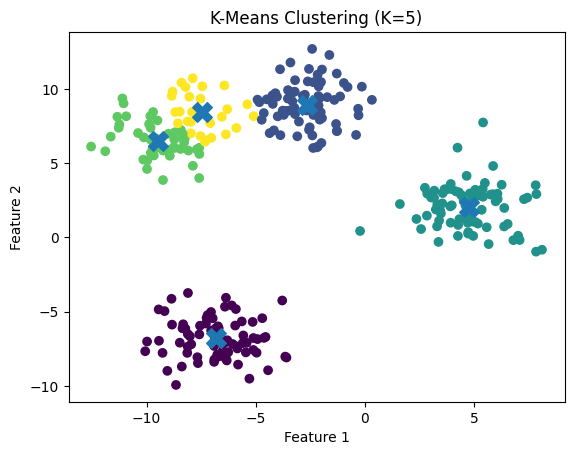

In [3]:
def plot_kmeans(X, k):
    kmeans = KMeans(n_clusters=k, n_init=10)
    labels = kmeans.fit_predict(X)
    centers = kmeans.cluster_centers_

    plt.figure()
    plt.scatter(X[:, 0], X[:, 1], c=labels)
    plt.scatter(centers[:, 0], centers[:, 1], marker='X', s=200)
    plt.title(f"K-Means Clustering (K={k})")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

# Generate plots
plot_kmeans(X, 2)
plot_kmeans(X, 3)
plot_kmeans(X, 5)

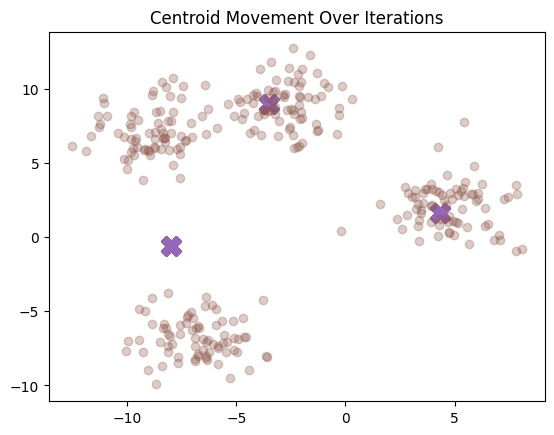

In [4]:
kmeans = KMeans(n_clusters=3, init='random', n_init=1, max_iter=1, random_state=42)

centroids_history = []

for i in range(5):
    kmeans.fit(X)
    centroids_history.append(kmeans.cluster_centers_)

plt.figure()
for centroids in centroids_history:
    plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200)

plt.scatter(X[:, 0], X[:, 1], alpha=0.3)
plt.title("Centroid Movement Over Iterations")
plt.show()

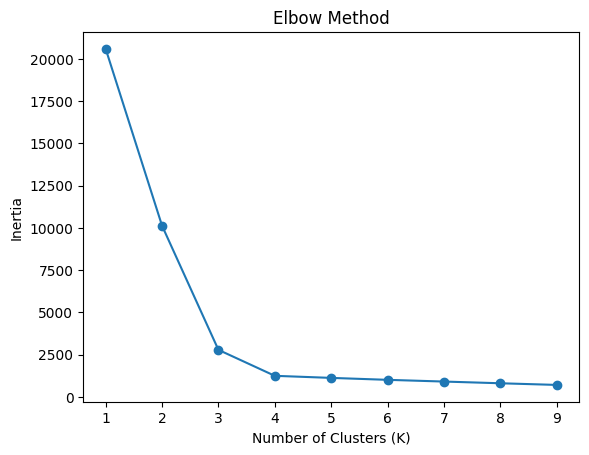

In [5]:
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

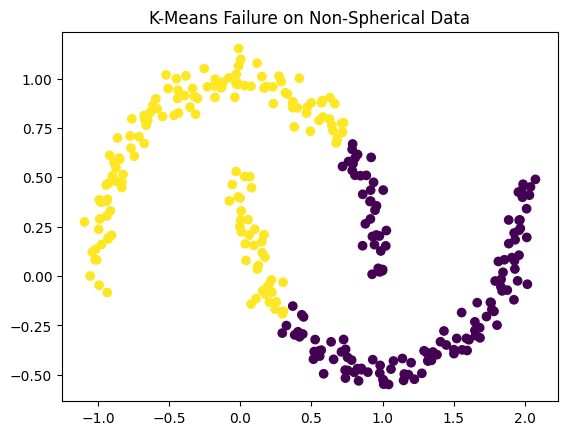

In [6]:
from sklearn.datasets import make_moons

X_moon, _ = make_moons(n_samples=300, noise=0.05)

kmeans = KMeans(n_clusters=2, n_init=10)
labels = kmeans.fit_predict(X_moon)

plt.figure()
plt.scatter(X_moon[:, 0], X_moon[:, 1], c=labels)
plt.title("K-Means Failure on Non-Spherical Data")
plt.show()

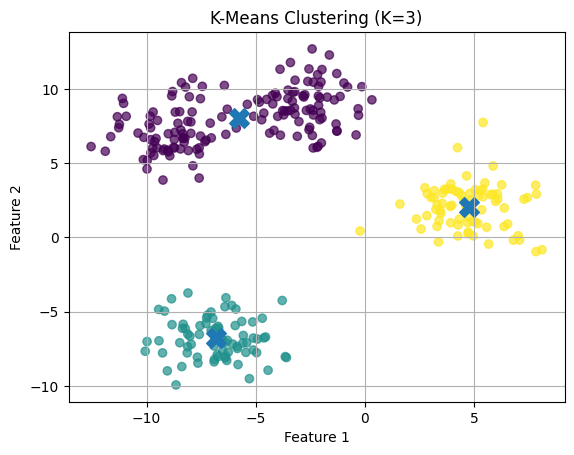

In [10]:
k = 3

kmeans = KMeans(n_clusters=k, n_init=10)
labels = kmeans.fit_predict(X)
centers = kmeans.cluster_centers_

plt.figure()
plt.scatter(X[:, 0], X[:, 1], c=labels, alpha=0.7)
plt.scatter(centers[:, 0], centers[:, 1], marker='X', s=200)

plt.title(f"K-Means Clustering (K={k})")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

In [8]:
for k, val in zip(K_range, inertia):
    print(f"K={k}, Inertia={val:.2f}")

K=1, Inertia=20587.34
K=2, Inertia=10128.26
K=3, Inertia=2786.74
K=4, Inertia=1251.35
K=5, Inertia=1128.47
K=6, Inertia=1013.87
K=7, Inertia=912.08
K=8, Inertia=810.73
K=9, Inertia=712.67


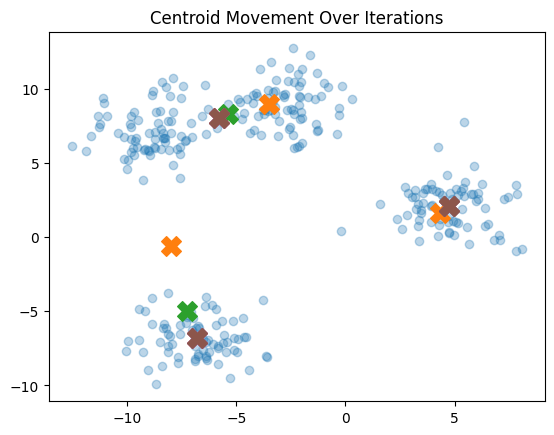

In [9]:
kmeans = KMeans(n_clusters=3, init='random', n_init=1, max_iter=10, random_state=42)

centroids_history = []

for i in range(1, 6):
    kmeans = KMeans(n_clusters=3, init='random', n_init=1, max_iter=i, random_state=42)
    kmeans.fit(X)
    centroids_history.append(kmeans.cluster_centers_)

plt.figure()
plt.scatter(X[:, 0], X[:, 1], alpha=0.3)

for centroids in centroids_history:
    plt.scatter(centroids[:, 0], centroids[:, 1], marker='X', s=200)

plt.title("Centroid Movement Over Iterations")
plt.show()